# 演習課題 (後期)

## 第1回

### 問題1

LLM を使った作りたいアプリを具体的に述べなさい。

Teamsやカレンダーなどのアプリと連携した、リマインダーアプリ

### 問題2

画像生成モデルを使った作りたいアプリを具体的に述べなさい。

顔写真と髪型を入力し、元の顔写真から髪型を変更した画像を生成するアプリ

### 問題3

提供されている LLM のサービスをひとつ選び、それについて調査しなさい。調査結果を以下にまとめなさい。

<br>

< ヒント >
- 開発元
- モデル
- 安全性
- Temperture の設定

| 観点        | 内容                                                                                                                                               |
|-------------|----------------------------------------------------------------------------------------------------------------------------------------------------|
| 開発元      | Perplexity AI, Inc.（米国カリフォルニア州、2022年設立、OpenAI・Meta等出身者チーム）                                            |
| モデル      | GPT-4、Claude 3、Gemini、独自モデル。「Perplexity Pro Search」「Deep Research」など用途別選択可                              |
| 安全性      | 情報源の自動記載／ハルシネーション少／個人情報は第三者非共有、削除時30日保持、機密入力は非推奨                              |
| Temperature | 出力の多様性・創造性を指定（0で保守的、1で多様性最大）、用途に応じて調整可能                                                     |

### 問題4

問題3で選んだ LLM を使って hallucination を起こし、それを記しなさい。また、hallucination が生じた理由を推測しなさい。

### 問題5

提供されている画像生成のサービスをひとつ選び、それについて調査しなさい。調査結果を以下にまとめなさい。

### 問題6

問題5で選んだ画像生成のサービスで生成した画像について、ステレオタイプや偏見が含まれていないかを確認しなさい。もしあれば、その理由について推測しなさい。

## 第2回

### 問題1

`rnn.ipynb` のコードを理解しながら確かめなさい。

### 問題2

`rnn.ipynb` において、train データと validation データに対する学習曲線(損失関数)をプロットしなさい。

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

### 問題3

`rnn.ipynb` において、予測値と実際の値をプロットしなさい。

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(test_actuals, label='Actual Price')
plt.plot(test_predictions, label='Predicted Price')
plt.xlabel('Time Step')
plt.ylabel('Dow Jones Price')
plt.title('RNN Prediction vs Actual (Test Set)')
plt.legend()
plt.grid(True)
plt.show()

### 問題4

`rnn.ipynb` にある RNN のハイパーパラメータを変更して、モデルの精度を高めなさい。

In [ ]:
# ハイパーパラメータを変更して再学習
HIDDEN_SIZE = 64  # 隠れ層のサイズを増やす
NUM_LAYERS = 2    # RNN層を2層に
BATCH_SIZE = 32   # バッチサイズを増やす
NUM_EPOCHS = 20   # エポック数を増やす
LEARNING_RATE = 0.005  # 学習率を調整

# データローダーの再作成
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# モデルの再定義
model = SimpleRNN(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []

print("Training Start (Hyperparameter Tuning)")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_batch_val, y_batch_val in val_loader:
            outputs_val = model(X_batch_val)
            val_loss = criterion(outputs_val, y_batch_val)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Train Loss: {avg_train_loss:.4f},  Val Loss: {avg_val_loss:.4f}")

print("Training Complete (Hyperparameter Tuning)")

test_loss, test_predictions, test_actuals = evaluate_model(model, test_loader)
print(f"Test Loss after tuning: {test_loss:.4f}")

### 問題5

`rnn.ipynb` では株価指数の予測を行っているが、他の時系列データを使ってモデルを構築して、時系列予測を行いなさい。

## 第3回

### 問題1

`tiktoken` を使って、英語や日本語の文章をトークン化しなさい。また、単語とトークンに違いがあるかを確認したりして、その結果を考察しなさい。

In [ ]:
# example

import tiktoken

text = "Hello World!"

enc = tiktoken.get_encoding("cl100k_base")

tokens = enc.encode(text)
print("Tokens:", tokens)

decoded = enc.decode(tokens)
print("Decoded:", decoded)

token_strings = [enc.decode([t]) for t in tokens]
print("Token pieces:", token_strings)

Tokens: [9906, 4435, 0]
Decoded: Hello World!
Token pieces: ['Hello', ' World', '!']


In [ ]:
# 英語と日本語の文章を用意
english_text = "I love natural language processing."
japanese_text = "私は自然言語処理が大好きです。"

# トークン化
english_tokens = enc.encode(english_text)
japanese_tokens = enc.encode(japanese_text)

# トークンを文字列に変換
english_token_strings = [enc.decode([t]) for t in english_tokens]
japanese_token_strings = [enc.decode([t]) for t in japanese_tokens]

print("English text:", english_text)
print("English tokens:", english_tokens)
print("English token pieces:", english_token_strings)
print("Number of words (English):", len(english_text.split()))
print("Number of tokens (English):", len(english_tokens))

print("\nJapanese text:", japanese_text)
print("Japanese tokens:", japanese_tokens)
print("Japanese token pieces:", japanese_token_strings)
print("Number of words (Japanese):", len(japanese_text.split()))
print("Number of tokens (Japanese):", len(japanese_tokens))

# 考察
print("\n考察:")
print("単語数とトークン数は一致しない。トークンは単語より細かい単位で分割されるため、特に日本語では単語分割が困難なためトークン数が多くなると考えられる。")

English text: I love natural language processing.
English tokens: [40, 3021, 5933, 4221, 8863, 13]
English token pieces: ['I', ' love', ' natural', ' language', ' processing', '.']
Number of words (English): 5
Number of tokens (English): 6

Japanese text: 私は自然言語処理が大好きです。
Japanese tokens: [86127, 15682, 37026, 61994, 78244, 45918, 252, 12870, 99, 22649, 29295, 27384, 53901, 50834, 38641, 1811]
Japanese token pieces: ['私', 'は', '自', '然', '言', '�', '�', '�', '�', '理', 'が', '大', '好', 'き', 'です', '。']
Number of words (Japanese): 1
Number of tokens (Japanese): 16

考察:
単語数とトークン数は一致しない。トークンは単語より細かい単位（サブワードや文字列断片）で分割されるため、特に日本語では単語分割が困難なためトークン数が多くなることがある。


### 問題2

"Attention Is All You Need" の論文の Abstract と Introduction, Conclusion を読んで、わからない概念や単語を調べ、内容を確認しなさい。


Attention Is All You Need: https://arxiv.org/abs/1706.03762

### 問題3

次の2つのベクトルの内積を求めよ。なお、LaTeX 表記で答えること。

$$
{a} =
\begin{pmatrix}
3 \\
4
\end{pmatrix}, \quad
{b} =
\begin{pmatrix}
2 \\
-1
\end{pmatrix}
$$

$$
{a} \cdot {b} = 3 \times 2 + 4 \times (-1) = 6 - 4 = 2
$$

### 問題4

ベクトル ${u}$ と ${v}$ があり、  

$$
{u} =
\begin{pmatrix}
1 \\
0 \\
1
\end{pmatrix}, \quad
{v} =
\begin{pmatrix}
0 \\
1 \\
1
\end{pmatrix}
$$

- (a) 内積 ${u} \cdot {v}$ を求めよ。  
- (b) ${u}$ と ${v}$ のなす角 $\theta$ を求めよ（内積と大きさの関係を利用する）：  
$$
\cos\theta = \frac{{u} \cdot {v}}{\|{u}\| \|{v}\|}
$$

### 問題5

2つのベクトルの cos類似度を求めなさい。

【参考】: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 問題で与えられたベクトル
u = np.array([[1, 0, 1]])
v = np.array([[0, 1, 1]])

# cos類似度の計算
cos_sim = cosine_similarity(u, v)[0][0]
print("cos類似度:", cos_sim)

cos類似度: 0.4999999999999999


### 問題6

問題5で求めた cos類似度から、2つのベクトルの角度を求めなさい。

【ヒント】: https://numpy.org/doc/stable/reference/generated/numpy.arccos.html

In [ ]:
import numpy as np

# cos_sim から角度を計算
theta_rad = np.arccos(cos_sim)

# 角度を度に変換
theta_deg = np.degrees(theta_rad)

print("2つのベクトルのなす角）:", theta_deg)

2つのベクトルのなす角）: 60.00000000000001


## 第4回

### 問題1

`torch.nn.Embedding` を使って、トークンを埋め込みなさい。なお、トークンは乱数で与えても良い。

In [ ]:
import torch
import torch.nn as nn

size = 3
dim = 5

embed = nn.Embedding(num_embeddings=size, embedding_dim=dim)
tokens = torch.randint(low=0, high=size, size=(4,), dtype=torch.long)

embedded = embed(tokens)
print("トークン:", tokens)
print("埋め込みベクトル:\n", embedded)

トークン: tensor([1, 2, 1, 2])
埋め込みベクトル:
 tensor([[-0.0506, -1.7640, -0.3689, -1.5484,  0.4910],
        [-1.4328, -0.0059, -1.5416, -0.9160, -1.2234],
        [-0.0506, -1.7640, -0.3689, -1.5484,  0.4910],
        [-1.4328, -0.0059, -1.5416, -0.9160, -1.2234]],
       grad_fn=<EmbeddingBackward0>)


### 問題2

`torch.nn.MultiheadAttention` について、query, key, value を乱数で与えて、その出力を得なさい。

In [ ]:
import torch
import torch.nn as nn

embed_dim = 8
num_head = 2
mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_head)

query = torch.rand(5, embed_dim)
key = torch.rand(5, embed_dim)
value = torch.rand(5, embed_dim)

attn_output, attn_output_weights = mha(query, key, value)

print("Attention出力\n", attn_output)
print("Attention重み\n", attn_output_weights)

Attention出力
 tensor([[ 0.2496, -0.0720, -0.0352,  0.3568,  0.2274, -0.1093, -0.1104, -0.2211],
        [ 0.2490, -0.0718, -0.0336,  0.3568,  0.2272, -0.1068, -0.1125, -0.2215],
        [ 0.2500, -0.0730, -0.0340,  0.3571,  0.2273, -0.1081, -0.1119, -0.2218],
        [ 0.2503, -0.0726, -0.0359,  0.3562,  0.2272, -0.1107, -0.1101, -0.2211],
        [ 0.2495, -0.0721, -0.0348,  0.3566,  0.2275, -0.1090, -0.1109, -0.2210]],
       grad_fn=<SqueezeBackward1>)
Attention重み
 tensor([[0.1980, 0.1931, 0.2108, 0.1977, 0.2004],
        [0.1940, 0.2018, 0.2073, 0.1917, 0.2052],
        [0.1913, 0.1970, 0.2137, 0.1921, 0.2060],
        [0.2016, 0.1920, 0.2107, 0.2033, 0.1924],
        [0.1989, 0.1971, 0.2075, 0.1984, 0.1981]], grad_fn=<SqueezeBackward1>)


### 問題3

`torch.nn.Transformer` に乱数を与えて、出力を得なさい。

In [ ]:
import torch
import torch.nn as nn

transformer = nn.Transformer(d_model=4, nhead=2)

src = torch.rand(2, 3, 4)
tgt = torch.rand(2, 3, 4)

output = transformer(src, tgt)

print("入力src:\n", src, "\n")
print("入力tgt:\n", tgt, "\n")

print("Transformer出力:", output)

入力src:
 tensor([[[0.3554, 0.9410, 0.9767, 0.2450],
         [0.9386, 0.7124, 0.4492, 0.4053],
         [0.8046, 0.7944, 0.6780, 0.0795]],

        [[0.5039, 0.1144, 0.1759, 0.6197],
         [0.4498, 0.9627, 0.4091, 0.3189],
         [0.6214, 0.8128, 0.2730, 0.6145]]]) 

入力tgt:
 tensor([[[0.0170, 0.7782, 0.0097, 0.7783],
         [0.1872, 0.3503, 0.7596, 0.5247],
         [0.6895, 0.9325, 0.4581, 0.0900]],

        [[0.3615, 0.8677, 0.6232, 0.6303],
         [0.1061, 0.3858, 0.3517, 0.5152],
         [0.0167, 0.5186, 0.9833, 0.8101]]]) 

Transformer出力: tensor([[[-1.5476,  0.3719, -0.0349,  1.2106],
         [-0.8521,  0.9679,  1.0215, -1.1373],
         [-1.1252,  1.3316,  0.5821, -0.7885]],

        [[-1.6282,  1.0968,  0.3136,  0.2178],
         [ 0.2089,  1.0223, -1.6532,  0.4220],
         [-1.6671,  0.2171,  0.4779,  0.9722]]],
       grad_fn=<NativeLayerNormBackward0>)


### 問題4

`sentence_transformers` を使って、いくつかの文章を埋め込み、それらの cos 類似度を測りなさい。

In [ ]:
from sentence_transformers import SentenceTransformer, util

# 1. 訓練済みのモデルをロード
model = SentenceTransformer("all-MiniLM-L6-v2")

# エンコードする文章のリスト
sentences = [
    "今日の天気は素晴らしいです。",
    "外はとても晴れています！",
    "彼はスタジアムへ車で行きました。",
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

# 2. 文章を埋め込みベクトルに変換
embeddings = model.encode(sentences)
print(embeddings.shape)


# 3. 埋め込みの類似度を計算
similarities = util.pytorch_cos_sim(embeddings, embeddings)
print(similarities)


(6, 384)
tensor([[ 1.0000,  0.6759,  0.5684,  0.2042,  0.1317,  0.0087],
        [ 0.6759,  1.0000,  0.4978,  0.0987,  0.1227,  0.0720],
        [ 0.5684,  0.4978,  1.0000, -0.0114,  0.0335,  0.1189],
        [ 0.2042,  0.0987, -0.0114,  1.0000,  0.6660,  0.1046],
        [ 0.1317,  0.1227,  0.0335,  0.6660,  1.0000,  0.1411],
        [ 0.0087,  0.0720,  0.1189,  0.1046,  0.1411,  1.0000]])


## 第5回

言語生成モデル [distilgpt2](https://huggingface.co/distilbert/distilgpt2) を Google Colab の GPU 上で試しなさい。

<br>

参考コード：
- https://huggingface.co/distilbert/distilgpt2/colab
- https://huggingface.co/distilbert/distilgpt2#how-to-get-started-with-the-model

In [2]:
!pip install transformers

In [6]:
from transformers import pipeline

# パイプライン準備（distilgpt2を指定）
generator = pipeline("text-generation", model="distilbert/distilgpt2", device=0)

# 入力文から続くテキスト生成
result = generator("Manners make the man", max_length=50)
print("結果:\n", result)


Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


結果:
 [{'generated_text': 'Manners make the man on the right stick, and they are doing it even more.\n\n\nIn the video, a man with a handgun is seen carrying a gun in his waistband and carrying a gun.\nThe man, identified only as 24-year-old David Shaffer, was shot to death by a man with a gun on his head.\nHe was shot by a man with a gun on his head.\nShaffer was shot to death by a man with a handgun on his head.\nAuthorities say the man was shot at by a man who was standing near an intersection with a construction worker.\nPolice say the man was standing near an intersection with a construction worker.\nThe man was shot at by a man with a gun on his head.\nShaffer was shot to death by a man with a gun on his head.'}]


## 第6回

### 問題1

ランダムウォーク $\{ X_n \}\ (n = 0, 1, 2, \cdots)$ を実装しなさい。なお、$ X_0 = 0,\ X_n = -1\ or\ +1 $, 最終到達点を
$$
S_n := X_0 + X_1 + \cdots + X_n
$$
と定義する。

In [3]:
import random

def random_walk(n, p=0.5, seed=None):
    """
    n: 最後の時刻 n (非負整数)
    p: +1 を出す確率 (デフォルト 0.5)
    seed: 乱数シード（指定しないと毎回異なる）
    """
    if seed is not None:
        random.seed(seed)

    X = [0]  # X_0 = 0
    for _ in range(n):
        step = 1 if random.random() < p else -1
        X.append(step)

    S = []
    cumulative_sum = 0
    for x in X:
        cumulative_sum += x
        S.append(cumulative_sum)

    return X, S

X, S = random_walk(10, seed=371)
print("X:", X)
print("S:", S)
print("最終到達点 S_n:", S[-1])

X: [0, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1]
S: [0, 1, 2, 1, 0, -1, 0, -1, -2, -1, -2]
最終到達点 S_n: -2


### 問題2

ランダムウォーク $\{ X_n \}$ を $n = 100$ まで試して、平均値と分散を求めなさい。

平均:
$$
\mu_n := \frac{\sum_{m=0}^{n} X_m}{n}
$$

分散:
$$
\sigma_n := \frac{\sum_{m=0}^{n} (X_m - \mu_n)^2}{n}
$$

$$

In [6]:
# ランダムウォークを n=100 まで実行して平均と分散を計算
n = 100
X, S = random_walk(n, seed=371)

# 問題の定義に従い X_0 ... X_n を n で割る
mu_n = sum(X) / n
sigma_n = sum((x - mu_n) ** 2 for x in X) / n

print(f"n = {n}")
print(f"X: {X}")
print(f"S: {S}")
print(f"平均 μ_n = {mu_n}")
print(f"分散 σ_n = {sigma_n}")
print(f"最終到達点 S_n = {S[-1]}")

n = 100
X: [0, 1, 1, -1, -1, -1, 1, -1, -1, 1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1, 1, -1, 1, -1, -1, -1, -1, -1, -1, 1, 1, 1, 1, -1, 1, 1, -1, -1, -1, 1, 1, 1, -1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, -1, -1, -1, 1, -1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, 1, 1, -1, -1, 1, -1, 1, -1, 1, -1, 1, 1, 1, 1, 1, -1, 1, 1, 1, 1, -1, 1, 1, 1, 1, 1, -1, 1, -1, 1, -1]
S: [0, 1, 2, 1, 0, -1, 0, -1, -2, -1, -2, -3, -4, -5, -4, -3, -2, -1, -2, -1, 0, -1, 0, -1, -2, -3, -4, -5, -6, -5, -4, -3, -2, -3, -2, -1, -2, -3, -4, -3, -2, -1, -2, -1, 0, 1, 0, 1, 2, 3, 4, 5, 4, 3, 2, 1, 2, 1, 2, 3, 2, 3, 4, 5, 6, 7, 6, 7, 6, 7, 8, 9, 8, 7, 8, 7, 8, 7, 8, 7, 8, 9, 10, 11, 12, 11, 12, 13, 14, 15, 14, 15, 16, 17, 18, 19, 18, 19, 18, 19, 18]
平均 μ_n = 0.18
分散 σ_n = 0.967924
最終到達点 S_n = 18


### 問題3

問題2において、$n$ を大きくしていくと平均と分散がどのように変化するか、確かめなさい。

In [9]:
def mu_n(X, n):
    return sum(X) / n

def sigma_n(X, n):
    mu = mu_n(X, n)
    return sum((x - mu) ** 2 for x in X) / n

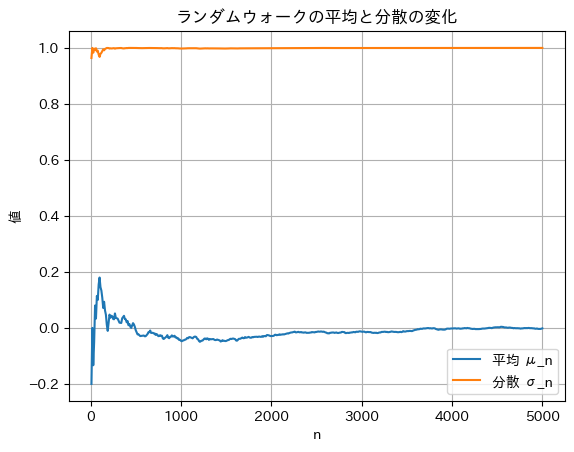

In [ ]:
import matplotlib.pyplot as plt
import japanize_matplotlib

n_max = 5000
step = 10
n_list = list(range(step, n_max + 1, step))

mu_list = []
sigma_list = []
for n in n_list:
    X, S = random_walk(n, seed=371)
    mu = mu_n(X, n)
    sigma = sigma_n(X, n)
    mu_list.append(mu)
    sigma_list.append(sigma)

plt.plot(n_list, mu_list, label="平均 μ_n")
plt.plot(n_list, sigma_list, label="分散 σ_n")
plt.xlabel("n")
plt.ylabel("値")
plt.title("ランダムウォークの平均と分散の変化")
plt.legend()
plt.grid()
plt.show()

### 問題4

$n = 100$ として、ランダムウォークを $1000$ 回試し、最終到達点 $S_{n=100}$ のヒストグラムを作りなさい。

Text(0, 0.5, '出現回数')

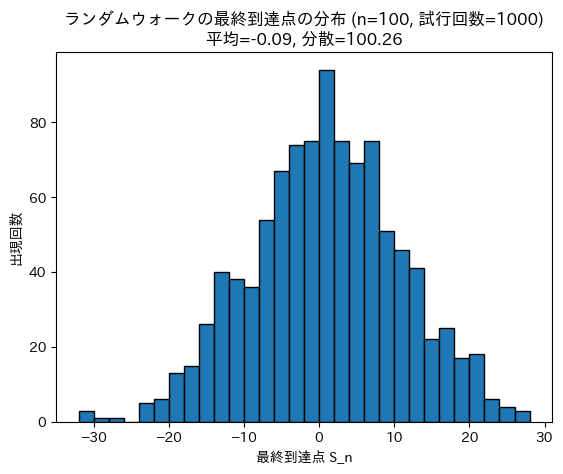

In [25]:
import random
import numpy as np

n = 100
trials_local = 1000

final_points = []
for _ in range(trials_local):
    _, S_tmp = random_walk(n,)
    final_points.append(S_tmp[-1])


mean_fp = np.mean(final_points)
var_fp = np.var(final_points)

plt.hist(final_points, bins=30, edgecolor="black")
plt.title(f"ランダムウォークの最終到達点の分布 (n={n}, 試行回数={trials_local})\n平均={mean_fp:.2f}, 分散={var_fp:.2f}")
plt.xlabel("最終到達点 S_n")
plt.ylabel("出現回数")

### 問題5

問題4のヒストグラムを正規化したものに、平均 $0$, 分散 $n$ の正規分布を合わせてプロットしなさい。なお、ヒストグラムの正規化は例えば `matplotlib.pyplot.hist(..., density=True, ...)` で指定できる。

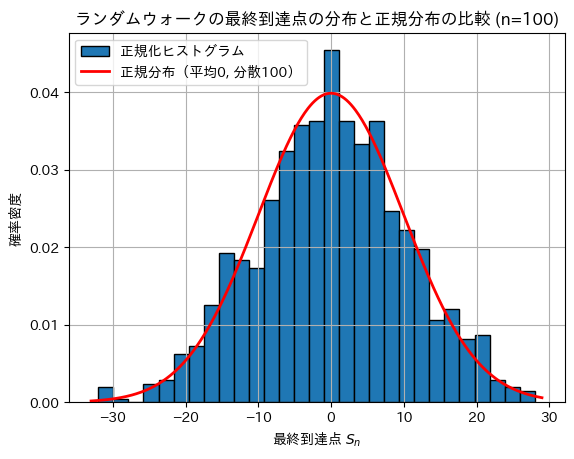

In [33]:
# 正規化ヒストグラムに平均0・分散nの正規分布を重ねてプロット

bins = np.linspace(min(final_points), max(final_points), 30)
sigma = np.sqrt(n)  # 標準偏差 = sqrt(分散=n)
x = np.linspace(bins.min() - 1, bins.max() + 1, 400)
pdf = 1.0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-x**2 / (2 * sigma**2))

plt.hist(final_points, bins=bins, density=True, edgecolor="black", label="正規化ヒストグラム")
plt.plot(x, pdf, "r-", lw=2, label=f"正規分布（平均0, 分散{n}）")
plt.xlabel("最終到達点 $S_n$")
plt.ylabel("確率密度")
plt.title(f"ランダムウォークの最終到達点の分布と正規分布の比較 (n={n})")
plt.legend()
plt.grid(True)
plt.show()

### 問題6

Stable Diffsion や DALL·E を使って、画像生成 AI を試しなさい。

#### 柴犬が紅葉の中で笑顔で座っている日本の秋の風景
モデル：seedream
<p align="center">
<img src="seedream_shiba.png" alt="柴犬が紅葉の中で笑顔で座っている日本の秋の風景" width="500"/>
</p>

### 参考

#### Diffusion Model
[J. Ho, A. Jain, and P. Abbeel, Denoising Diffusion Probabilistic Models, Adv. Neural Inf. Process. Syst. 33 (2020).](https://proceedings.neurips.cc/paper/2020/hash/4c5bcfec8584af0d967f1ab10179ca4b-Abstract.html)
- 現在の画像生成 AI の起点となったモデル

#### Machine Learning (機械学習)
> Machine learning is programming computers to optimize a performance criterion using example data or past experience.

E. Alpaydin, Introduction to Machine Learning, 3rd ed., MIT Press, Cambridge, MA, 2014.

#### 生成 AI (Generative AI)
> The term generative AI is used to describe deep learning models that generate outputs in the form of images, video, audio, text, candidate drug molecules, or other modalities.

[C. M. Bishop and H. Bishop, Deep Learning: Foundations and Concepts, Springer Nature, 2023.](https://www.bishopbook.com)

#### 生成モデル (Generative Model)
> Generative models use machine learning algorithms to learn a distribution from a set of training data and then generate new examples from that distribution.

[C. M. Bishop and H. Bishop, Deep Learning: Foundations and Concepts, Springer Nature, 2023.](https://www.bishopbook.com)


#### 画像生成モデル一覧

| 開発元           | サービス名        |
|-----------------|----------------|
| OpenAI           | DALL·E         |
| Stability AI     | Stable Diffusion |
| Midjourney       | Midjourney     |
| Google DeepMind  | Imagen         |

## 第7回

多腕 Bandit 問題について、Greedy な行動と$\varepsilon$-greedy 法、それぞれを実装する。

以下に使用するライブラリを記す。各自の環境に応じて、インストールしなさい。
- 強化学習：https://gymnasium.farama.org
- 多腕 Bandit 問題：https://github.com/foreverska/buffalo-gym/

次に、多腕 Bandit 問題のコード例を示す。
- Bandit の数：`arms`
- レバーが引かれる Bandit の番号：`action`
- レバーを引いて、得られた報酬：`reward`

In [1]:
import gymnasium as gym
import buffalo_gym

env = gym.make("Buffalo-v0", arms=2)

obs, _ = env.reset()  # Resets the state at the beginning of the episode.

action = 1
obs, reward, done, truncated, info = env.step(action)

reward

np.float64(8.972472583477126)

### 問題1

Greedy な行動を実装しなさい。

In [79]:
def greedy_action(arms=5, episodes=100, seed=10):
    random.seed(seed)
    env = gym.make("Buffalo-v0", arms=arms)
    obs, _ = env.reset()

    rewards = [0] * arms
    counts = [0] * arms
    total = 0

    for action in range(arms):
        reward = env.step(action)[1]
        counts[action] += 1
        rewards[action] += (reward - rewards[action]) / counts[action]
        total += reward

        obs, _ = env.reset()

    for episode in range(episodes - arms):
        action = np.argmax(rewards)
        reward = env.step(action)[1]
        counts[action] += 1
        rewards[action] += (reward - rewards[action]) / counts[action]
        total += reward

        obs, _ = env.reset()

    return rewards, counts, total
rewoards, counts, total = greedy_action()

print("各アームの平均報酬:", [f"{r:.4f}" for r in rewoards])
print("各アームの選択回数:", counts)
print("合計報酬:", f"{total:.4f}")

各アームの平均報酬: ['0.9913', '3.0980', '1.0331', '4.6264', '0.5967']
各アームの選択回数: [1, 1, 1, 96, 1]
合計報酬: 449.8575


### 問題2

$\varepsilon$-greedy 法を実装しなさい。

In [113]:
def epsilon_greedy_action(arms=5, episodes=100, epsilon=0.1, seed=10):
    random.seed(seed)
    env = gym.make("Buffalo-v0", arms=arms)
    obs, _ = env.reset()

    rewards = [0] * arms
    counts = [0] * arms
    total = 0

    for _ in range(episodes):
        if random.random() < epsilon:
            action = random.randint(0, arms - 1)
        else:
            action = np.argmax(rewards)

        reward = env.step(action)[1]
        counts[action] += 1
        rewards[action] += (reward - rewards[action]) / counts[action]
        total += reward

        obs, _ = env.reset()

    return rewards, counts, total

rewards, counts, total = epsilon_greedy_action()

print("各アームの平均報酬:", [f"{r:.4f}" for r in rewards])
print("各アームの選択回数:", counts)
print("合計報酬:", f"{total:.4f}")

各アームの平均報酬: ['4.7028', '4.0224', '1.7105', '6.3661', '0.0000']
各アームの選択回数: [78, 15, 3, 4, 0]
合計報酬: 457.7477


### 問題3

Bandit 数 `arms` を5、エピソード数を 100 にして、$\varepsilon$-greedy 法を試しなさい。そして、最終的に得られた報酬の合計値を求めなさい。

In [115]:
rewards, counts, total = epsilon_greedy_action(arms=5, epsilon=0.3, episodes=100)
print("各アームの平均報酬:", [f"{r:.4f}" for r in rewards])
print("各アームの選択回数:", counts)
print("合計報酬:", f"{total:.4f}")

各アームの平均報酬: ['1.7107', '2.5420', '2.3060', '4.7623', '4.0887']
各アームの選択回数: [7, 7, 7, 71, 8]
合計報酬: 416.7461


### 問題4

問題3の設定で、なるべく報酬の合計値が高くなるように $\varepsilon$ を調整しなさい。

In [125]:
# 各 ε での100回試行した平均合計報酬
for epsilon in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    total = 0
    for _ in range(100):
        rewards, counts, t = epsilon_greedy_action(arms=5, epsilon=epsilon, episodes=100)
        total += t
    print(f"ε = {epsilon}")
    print(f"平均合計報酬: {total / 100:.4f}")
    print()

ε = 0.1
平均合計報酬: 397.2795

ε = 0.2
平均合計報酬: 400.5686

ε = 0.3
平均合計報酬: 406.0096

ε = 0.4
平均合計報酬: 400.1162

ε = 0.5
平均合計報酬: 396.1810

ε = 0.6
平均合計報酬: 404.4965

ε = 0.7
平均合計報酬: 404.2365

ε = 0.8
平均合計報酬: 399.7877

ε = 0.9
平均合計報酬: 395.1874



### 問題5

Greedy な行動と $\varepsilon$-greedy 法を比べて、どちらが報酬の合計値が大きいか、シミュレーションして確かめなさい。

Greedy法 平均合計値: 403.3621, 標準偏差: 32.3776
Epsilon-greedy法 (ε=0.35) 平均合計値: 393.7331, 標準偏差: 41.0805


C:\Users\ITWhiteHacker\AppData\Local\Temp\ipykernel_14420\4090190900.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([greedy, eps], labels=['Greedy', f'ε-greedy (ε={eps_value})'])


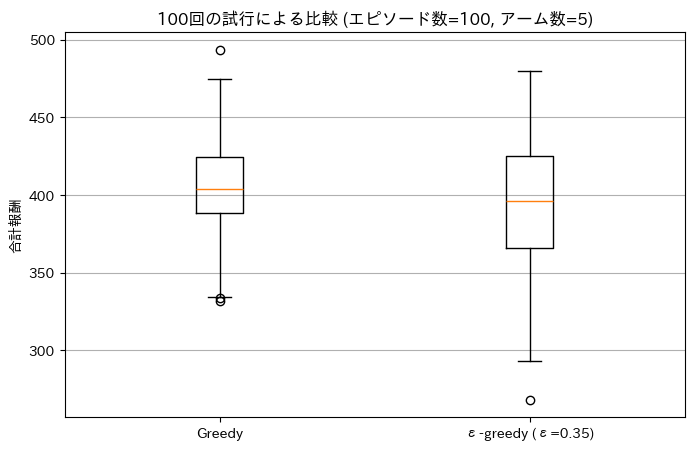

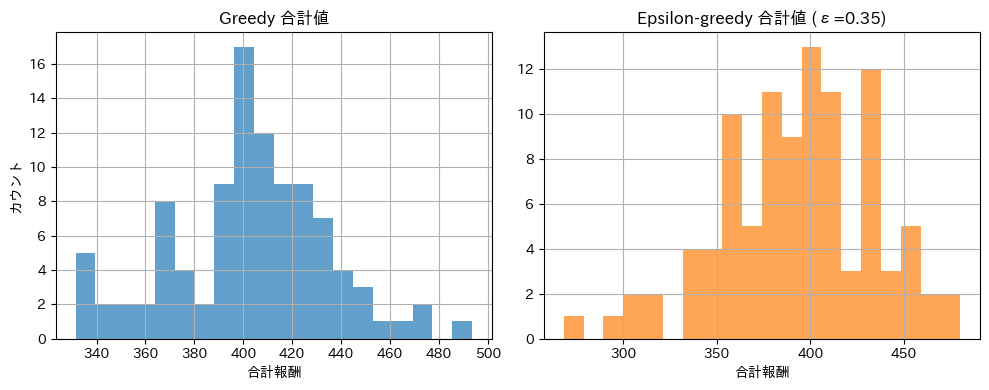

In [ ]:
# Greedy法とε-greedy法の比較
# 比較実験: 各手法を100回ずつ実行して合計報酬を収集・プロット
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

def run_comparison(trials=100, arms=5, episodes=100, eps_value=0.35):
    greedy, eps = zip(*[
        (
            greedy_action(arms=arms, episodes=episodes, seed=i)[2],
            epsilon_greedy_action(arms=arms, episodes=episodes, epsilon=eps_value, seed=i)[2]
        )
        for i in range(trials)
    ])
    greedy = np.array(greedy, dtype=float)
    eps = np.array(eps, dtype=float)

    print(f"Greedy法 平均合計値: {greedy.mean():.4f}, 標準偏差: {greedy.std():.4f}")
    print(f"Epsilon-greedy法 (ε={eps_value}) 平均合計値: {eps.mean():.4f}, 標準偏差: {eps.std():.4f}")

    plt.figure(figsize=(8,5))
    plt.boxplot([greedy, eps], labels=["Greedy", f"ε-greedy (ε={eps_value})"])
    plt.ylabel("合計報酬")
    plt.title(f"{trials}回の試行による比較 (エピソード数={episodes}, アーム数={arms})")
    plt.grid(True, axis="y")
    plt.show()

    plt.figure(figsize=(10,4))
    for idx, (totals, title, color) in enumerate([
        (greedy, "Greedy 合計値", "C0"),
        (eps, f"Epsilon-greedy 合計値 (ε={eps_value})", "C1")
    ]):
        plt.subplot(1,2,idx+1)
        plt.hist(totals, bins=20, color=color, alpha=0.7)
        plt.title(title)
        plt.xlabel("合計報酬")
        plt.ylabel("カウント" if idx==0 else "")
        plt.grid(True)
    plt.tight_layout()
    plt.show()

run_comparison()


### 問題6

$\varepsilon$-greedy 法を多腕 Bandit 問題以外に使う方法を考えなさい。

- Web広告表示最適化
- レコメンドシステム

# 強化学習

## 基本概念

### Agent
行動する主体のこと。例：ゲームのプレーヤー. ロボット. 囲碁のプログラム.

### 環境 Envirnment
Agent が行動する場。例：ゲーム機. ロボットのいる部屋. 囲碁の盤面.

### Agent と環境
Agent はある環境に置かれ、その状態と報酬に基づいて、行動する。

### Episode
ゲームが始まってから終わるまでの一連の出来事。

### 強化学習の目的
Agent が得る報酬の合計値を最大にするような行動を学習すること

## 多腕 Bandit 問題

### 枠組み
- 環境：複数のスロットマシン
- Agent：スロットマシンのプレーヤー
- 行動：スロットマシンを選び、レバーを引くこと。
- 報酬：行動の結果、得られるコインの枚数。
- 状態：スロットマシン自体は変化しないので、今回は考える必要がない。
- Episode：1回、レバーを引くことを 1 episode と数える。

### Greedy な行動
それまでのプレイ結果をもとに、最も報酬の平均値が高いスロットマシンを選ぶこと。

### $\varepsilon$-greedy 法
$\varepsilon$ の確率でランダムに行動を選び、$1 - \varepsilon$ の確率で Greedy な行動を選ぶ手法。